We use a noise equivalent angle (NEA) of 1.93 with STRAP in the MAOS sims. I want to know what magnitude guide star that corresponds to so I can set the same signal level in TRICK

In [6]:
from paarti.utils import maos_utils as mu
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

In [7]:
# Double check I know how this all works
ngs_mag = 10
wfs = "STRAP"
r0z = 0.14
zenith_angle = 30 * u.deg
r0 = r0z * np.cos(zenith_angle.to_value(u.radian))**(3/5)
wfs_int_time = 1/472
SNR, sigma_theta, Np, Nb = mu.keck_nea_photons(ngs_mag, wfs, r0, wfs_int_time=wfs_int_time)
print(sigma_theta)

Assumptions:
  Wave-Front Sensor       = STRAP
  Pupil Aperture Diameter = 9.57 m (assumed square)
  Throughput (w QE)       = 0.32
  Plate Scale             = 1.400 arcsec/pix
  Spot Size Diameter      = 1.183 arcsec
  Filter                  = R
  Readnoise               = 0.0 e-
  Pixels per Subaperture  = 4
  Integration Time        = 0.0021 s
  Guide Star Magnitude    = 10.00

Outputs:
  N_photons from star (powfs.siglev for MAOS config): 64529.033
  N_photons per pixel from background (powfs.bkgrnd): 9.594
  SNR: 253.950
  NEA (powfs.nearecon): 4.659 mas
4.659470177207891


Assumptions:
  Wave-Front Sensor       = STRAP
  Pupil Aperture Diameter = 9.57 m (assumed square)
  Throughput (w QE)       = 0.32
  Plate Scale             = 1.400 arcsec/pix
  Spot Size Diameter      = 1.183 arcsec
  Filter                  = R
  Readnoise               = 0.0 e-
  Pixels per Subaperture  = 4
  Integration Time        = 0.0021 s
  Guide Star Magnitude    = 6.00

Outputs:
  N_photons from star (powfs.siglev for MAOS config): 2568947.088
  N_photons per pixel from background (powfs.bkgrnd): 9.594
  SNR: 1602.782
  NEA (powfs.nearecon): 0.738 mas
Assumptions:
  Wave-Front Sensor       = STRAP
  Pupil Aperture Diameter = 9.57 m (assumed square)
  Throughput (w QE)       = 0.32
  Plate Scale             = 1.400 arcsec/pix
  Spot Size Diameter      = 1.183 arcsec
  Filter                  = R
  Readnoise               = 0.0 e-
  Pixels per Subaperture  = 4
  Integration Time        = 0.0021 s
  Guide Star Magnitude    = 6.01

Outputs:
  N_photons from star (powfs.siglev fo

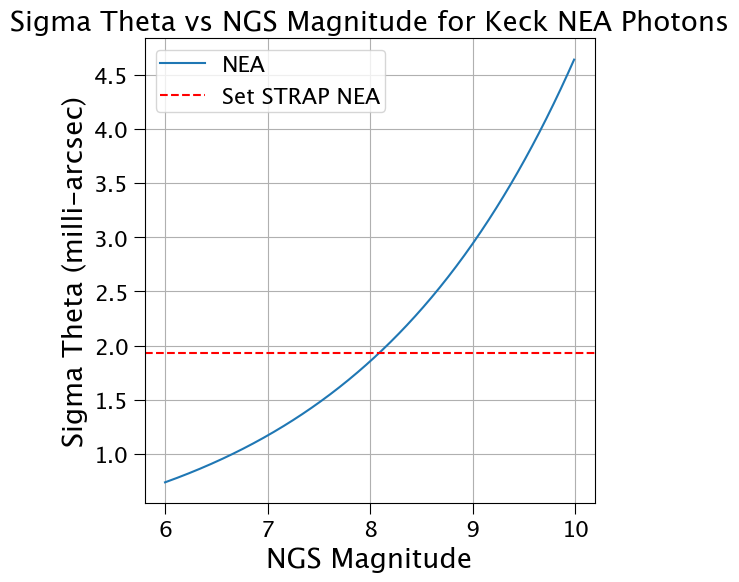

In [12]:
# Do a search over a range of ngs_mags to find the sigma_theta closest to 1.93
ngs_mags = np.arange(6, 10, 0.01)
sigma_thetas = []
for ngs_mag in ngs_mags:
    wfs = "STRAP"
    r0z = 0.14
    zenith_angle = 30 * u.deg
    r0 = r0z * np.cos(zenith_angle.to_value(u.radian))**(3/5)
    wfs_int_time = 1/472
    SNR, sigma_theta, Np, Nb = mu.keck_nea_photons(ngs_mag, wfs, r0, wfs_int_time=wfs_int_time)
    sigma_thetas.append(sigma_theta)
    
# Plot results
plt.plot(ngs_mags, sigma_thetas, label="NEA")
plt.axhline(1.93, color='r', linestyle='--', label="Set STRAP NEA")
plt.xlabel('NGS Magnitude')
plt.ylabel('Sigma Theta (milli-arcsec)')
plt.title('Sigma Theta vs NGS Magnitude for Keck NEA Photons')
plt.grid()
plt.legend()
plt.show()


In [13]:
# Use code to find the ngs_mag that gives sigma_theta closest to 1.93
closest_index = np.argmin(np.abs(np.array(sigma_thetas) - 1.93))
closest_ngs_mag = ngs_mags[closest_index]
print(f"Closest NGS Magnitude for sigma_theta ~ 1.93: {closest_ngs_mag:.2f}, Sigma Theta: {sigma_thetas[closest_index]:.2f}")

Closest NGS Magnitude for sigma_theta ~ 1.93: 8.09, Sigma Theta: 1.93


In [14]:
# Now plug this NGS magnitude in for TRICK
ngs_mag = closest_ngs_mag
wfs = "TRICK-K"
r0z = 0.14
zenith_angle = 30 * u.deg
r0 = r0z * np.cos(zenith_angle.to_value(u.radian))**(3/5)
wfs_int_time = 1/472
SNR, sigma_theta, Np, Nb = mu.keck_nea_photons(ngs_mag, wfs, r0, wfs_int_time=wfs_int_time)

Assumptions:
  Wave-Front Sensor       = TRICK-K
  Pupil Aperture Diameter = 9.57 m (assumed square)
  Throughput (w QE)       = 0.50
  Plate Scale             = 0.040 arcsec/pix
  Spot Size Diameter      = 0.074 arcsec
  Filter                  = K
  Readnoise               = 11.188 e-
  Pixels per Subaperture  = 16
  Integration Time        = 0.0021 s
  Guide Star Magnitude    = 8.09

Outputs:
  N_photons from star (powfs.siglev for MAOS config): 137134.570
  N_photons per pixel from background (powfs.bkgrnd): 3.446
  SNR: 367.569
  NEA (powfs.nearecon): 0.201 mas


In [15]:
# Now plug this NGS magnitude in for TRICK
ngs_mag = closest_ngs_mag
wfs = "TRICK-H"
r0z = 0.14
zenith_angle = 30 * u.deg
r0 = r0z * np.cos(zenith_angle.to_value(u.radian))**(3/5)
wfs_int_time = 1/472
SNR, sigma_theta, Np, Nb = mu.keck_nea_photons(ngs_mag, wfs, r0, wfs_int_time=wfs_int_time)

Assumptions:
  Wave-Front Sensor       = TRICK-H
  Pupil Aperture Diameter = 9.57 m (assumed square)
  Throughput (w QE)       = 0.45
  Plate Scale             = 0.060 arcsec/pix
  Spot Size Diameter      = 0.055 arcsec
  Filter                  = H
  Readnoise               = 11.188 e-
  Pixels per Subaperture  = 16
  Integration Time        = 0.0021 s
  Guide Star Magnitude    = 8.09

Outputs:
  N_photons from star (powfs.siglev for MAOS config): 123990.386
  N_photons per pixel from background (powfs.bkgrnd): 3.355
  SNR: 349.238
  NEA (powfs.nearecon): 0.157 mas
